# Does "momentum" work in bonds the way it works in stocks? 📈
### Corporate-bond momentum — real for single high-yield names, invisible on a basket of ETFs

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Lookback stable%3F: Not supported](https://img.shields.io/badge/Lookback_stable%3F-Not_supported-8b949e?style=flat-square)

Momentum is the closest thing finance has to a law: stocks that beat their peers keep beating them for a while. A well-cited 2013 paper (Jostova and co-authors) found the same thing in **corporate bonds** — but specifically in *individual high-yield* bonds. The obvious retail question: can you just do it with bond **ETFs**? Rank a handful of credit funds on their recent return, buy the winners, short the losers?

We tried. It doesn't work — and there's a clean reason why.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 11 credit + Treasury bond ETFs, total return, 2007→2026. Each chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bond_momentum import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.drop_partial_last_month(data.load_real())
    MP = st.to_monthly(PRICES)
    BK = st.wml_book(MP)
else:
    PRICES = MP = BK = None
print("real cache present:", HAVE_REAL, "| WML holding months:",
      (0 if BK is None else len(BK)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2007-01-03', 'end': '2026-06-30', 'fp': '1f2efa58efab', 'n_rows': 4903, 'n_names': 11, 'n_months': 234, 'n': 216, 'mean_pct': 1.63, 'vol_pct': 10.23, 'sharpe': 0.16, 'hac_t': 0.8, 'iid_t': 0.67, 'hit_pct': 51.4, 'wilson': (44.8, 58.0), 'max_dd_pct': -24.2, 'worst_pct': -18.88, 'turnover_pct': 50.5, 'avg_leg': 3.7, 'avg_ranked': 10.4, 'placebo_real_pct': 1.63, 'placebo_mean_pct': 0.02, 'placebo_sd_pct': 1.51, 'placebo_p': 0.152, 'placebo_n': 2000, 'lookbacks': {'6m (headline)': (1.63, 0.16, 0.8, 216), '12m': (-1.32, -0.14, -0.54, 210), '12-1': (-1.19, -0.13, -0.54, 209), '3m': (1.93, 0.2, 0.93, 219)}, 'eras': {'2007-2013 (Jostova era)': (2.51, 0.17, 0.54, 67), '2014-2026 (post-pub)': (1.23, 0.16, 0.6, 149)}, 'costs': {'5 bps + 50 borrow': (0.82, 0.08, 0.4), '10 bps + 50 borrow': (0.52, 0.05, 0.25), '20 bps + 100 borrow': (-0.59, -0.06, -0.28)}, 'break_even_bps': 26.8, 'hyg_mean_pct': 5.29, 'hyg_sharpe': 0.52, 'hyg_t': 2.47, 'long_leg_pct': 5.64, 'short_leg_pct': 4.02, 'corr_hyg': -0.1, 'syn': {0.0: (-0.2, -0.11), 0.06: (3.2, 2.51), 0.12: (11.0, 5.3), 0.2: (24.5, 8.59)}, 'syn_null_mean_t': 0.14, 'syn_null_fire': 0, 'syn_null_seeds': 20}


real cache present: True | WML holding months: 216


## The answer first

| Question | Answer |
|---|---|
| Do winner bond-ETFs keep beating loser bond-ETFs? | **Not measurably.** The winners-minus-losers spread earns **+1.6%/yr** — but that's statistical noise (it could just as easily be zero), and the winners beat the losers on only **51%** of months, a coin flip. |
| Is the '6-12 month' rule robust? | **No.** Rank on the last **6** months and the tiny edge is positive; rank on the last **12** and it turns *negative*. A real pattern doesn't change its sign when you nudge the lookback inside the range the claim itself endorses. |
| Can you trade it? | **No.** You'd need costs below ~**27 bps** a trade just to break even, and the spread turns over half the book every month. At realistic costs the net return is a rounding error, then negative. |
| Is there *any* edge in these ETFs? | **Yes — just owning high-yield credit** (HYG returned +5.3%/yr, a real risk premium). But that's a *level* bet, not momentum — and the momentum spread is built to cancel it out. |

> The famous bond-momentum result is real where it was found (single high-yield bonds). It just doesn't survive the trip to a basket of ETFs.

## 1 · The claim

> *"Momentum is everywhere. Rank corporate bonds on their trailing 6-12 month return, buy the recent winners and short the recent losers, and you'll earn a premium — just like in stocks."*

This traces to **Jostova, Nikolova, Philipov & Stahel (2013)**, who documented significant momentum in corporate bonds over 1973-2011. The crucial detail, which the retail version usually drops: they found it **concentrated in high-yield (junk) bonds** and *weak-to-absent in investment-grade*. Momentum in bonds is a credit-quality story.

## 2 · So what?

If a simple monthly rank-and-rotate on liquid bond **ETFs** captured that premium, it would be a genuinely easy, mechanical fixed-income strategy anyone could run from a brokerage account — no single-bond illiquidity, no dealer spreads on odd lots. That's exactly why it's worth testing *and* worth being suspicious of: the gap between "true in the academic single-name cross-section" and "tradable in a dozen ETFs" is where a lot of factor strategies quietly die.

## 3 · How would we even know?

- **The universe.** 11 credit + Treasury bond ETFs (IG, high-yield, EM, bank loans, fallen angels, and short/intermediate/long Treasuries), total return, 2007→2026.
- **The sort.** Every month-end, rank on trailing 6-month return; go long the top third, short the bottom third; hold one month; rebalance.
- **The luck check.** Randomly reshuffle which ETF gets which momentum rank 2,000 times — how often does a *random* ranking beat the real one?
- **The robustness check.** Slide the lookback across the 6-12 month range the claim names. A real signal keeps its sign.
- **The trade check.** Charge realistic costs both ways, make the short leg pay borrow, and find the break-even.

## 4 · The teardown — let's actually look

**First, the headline spread.** How much does buying winners and shorting losers actually make, and is it distinguishable from zero?

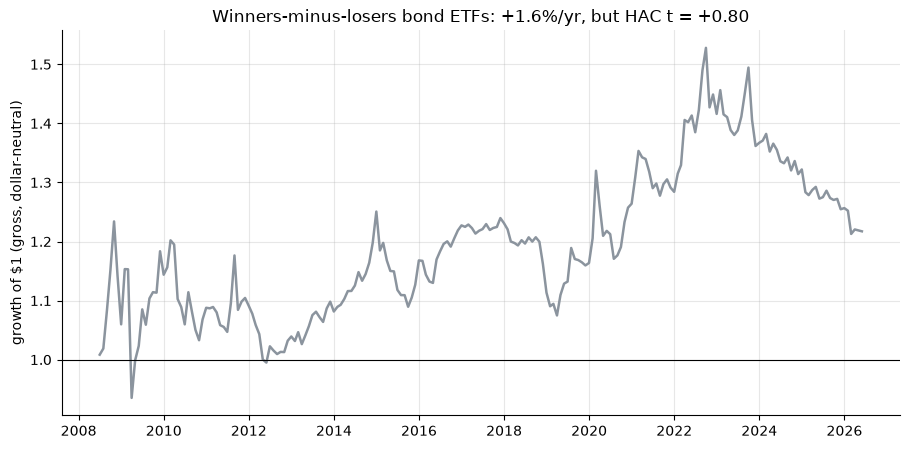

WML +1.63%/yr, HAC t = +0.80 (the bar is 2.0)


In [2]:
if HAVE_REAL:
    s = st.summary(BK['wml_gross'])
    eq = (1 + BK['wml_gross']).cumprod()
    mean_pct, t = s['mean']*100, s['tstat']
else:
    mean_pct, t = R['mean_pct'], R['hac_t']
    idx = pd.date_range('2008-07-31', periods=R['n'], freq='ME')
    rng = np.random.default_rng(795)
    eq = pd.Series((1+rng.normal(R['mean_pct']/100/12, R['vol_pct']/100/np.sqrt(12), R['n'])).cumprod(), index=idx)
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.plot(eq.index, eq.values, color=GREY, lw=1.8)
ax.axhline(1.0, c='k', lw=.8)
ax.set_ylabel('growth of $1 (gross, dollar-neutral)')
ax.set_title(f'Winners-minus-losers bond ETFs: {mean_pct:+.1f}%/yr, but HAC t = {t:+.2f}')
plt.tight_layout(); plt.show()
print(f'WML {mean_pct:+.2f}%/yr, HAC t = {t:+.2f} (the bar is 2.0)')

A gently rising line that could just as easily be flat. The spread makes **+1.6%/yr** over ~18 years, but the honest statistic is **HAC *t* = +0.80** — the desk bar is 2.0, and this doesn't come close. Along the way it drops **-24%** and has a single **-18.9%** month. This is noise with a slight upward tilt.

**Is even that tilt real, or could a random ranking do as well?**

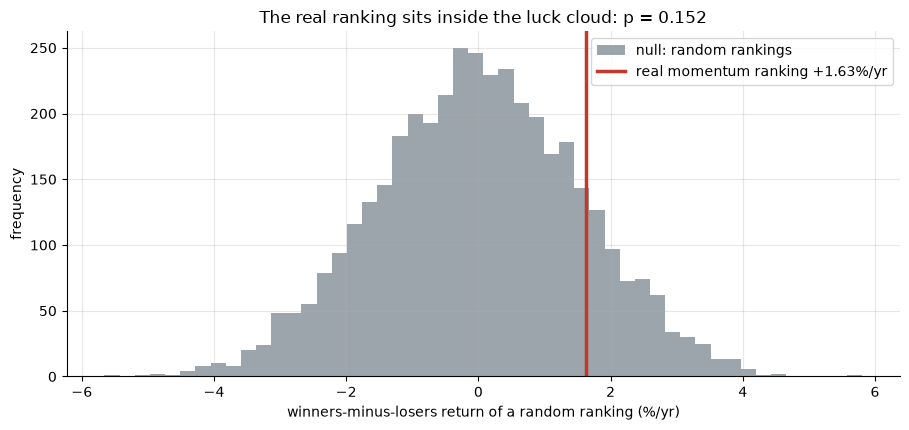

real +1.63%/yr vs random rankings; p = 0.152 (a random ranking wins ~1 time in 7)


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(MP, n_perm=800)
    obs = pl['real_mean_ann']*100
    rng = np.random.default_rng(795)
    draws = rng.normal(pl['placebo_mean_ann']*100, pl['placebo_sd_ann']*100, 4000)
    p = pl['p_value']
else:
    obs, p = R['placebo_real_pct'], R['placebo_p']
    rng = np.random.default_rng(795)
    draws = rng.normal(R['placebo_mean_pct'], R['placebo_sd_pct'], 4000)
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='null: random rankings')
ax.axvline(obs, c=RED, lw=2.5, label=f'real momentum ranking {obs:+.2f}%/yr')
ax.set_xlabel('winners-minus-losers return of a random ranking (%/yr)')
ax.set_ylabel('frequency')
ax.set_title(f'The real ranking sits inside the luck cloud: p = {R["placebo_p"]:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'real {obs:+.2f}%/yr vs random rankings; p = {R["placebo_p"]:.3f} '
      '(a random ranking wins ~1 time in 7)')

The real momentum ranking (red line) sits comfortably **inside** the cloud of what random rankings produce: **p = 0.152**. A coin-flip ranking beats the momentum ranking about one time in seven. There's no signal being detected here.

**Now the check that really sinks it: does the '6-12 month' rule even keep its sign?**

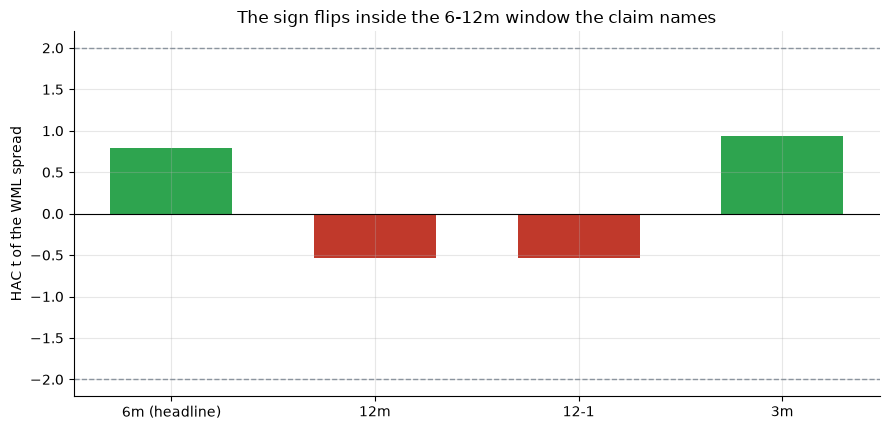

{'6m (headline)': 0.8, '12m': -0.54, '12-1': -0.54, '3m': 0.93}


In [4]:
labels = list(R['lookbacks']); ts = [R['lookbacks'][k][2] for k in labels]
if HAVE_REAL:
    ts = []
    for lb, sk in ((6,0),(12,0),(12,1),(3,0)):
        ts.append(st.summary(st.wml_book(MP, lookback=lb, skip=sk)['wml_gross'])['tstat'])
fig, ax = plt.subplots(figsize=(9.0, 4.4))
cols = [GREEN if t>0 else RED for t in ts]
ax.bar(labels, ts, color=cols, width=.6)
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(-2, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('HAC t of the WML spread')
ax.set_title('The sign flips inside the 6-12m window the claim names')
plt.tight_layout(); plt.show()
print({l: round(t,2) for l,t in zip(labels, ts)})

This is the tell. Rank on the last **6** months and the spread is faintly positive; rank on the last **12** (or 12-skip-1, the textbook equity-momentum formation) and it goes faintly **negative**. Not one bar clears the bar in either direction. A real anomaly is stable across nearby, equally-reasonable lookbacks — this one changes its mind across the exact 6-12 month range the claim endorses.

**Finally: is there any edge in these ETFs at all?**

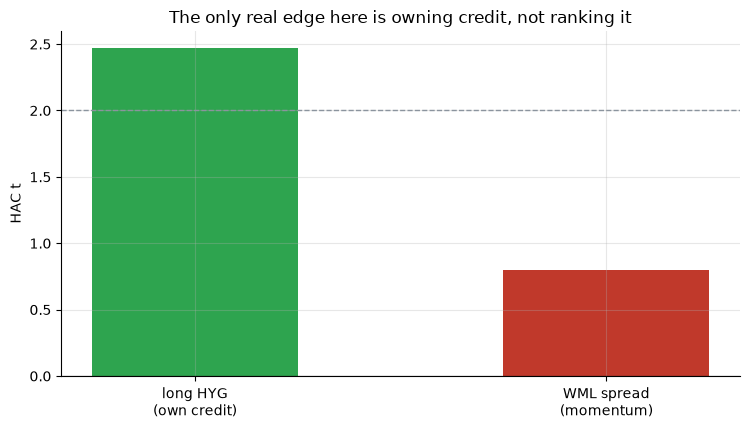

long HYG t = +2.47  vs  momentum spread t = +0.80


In [5]:
if HAVE_REAL and 'HYG' in MP.columns:
    hy = st.summary(MP['HYG'].pct_change().dropna())
    wl = st.summary(BK['wml_gross'])
    pairs = [('long HYG\n(own credit)', hy['tstat'], GREEN), ('WML spread\n(momentum)', wl['tstat'], RED)]
else:
    pairs = [('long HYG\n(own credit)', R['hyg_t'], GREEN), ('WML spread\n(momentum)', R['hac_t'], RED)]
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar([p[0] for p in pairs], [p[1] for p in pairs], color=[p[2] for p in pairs], width=.5)
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('HAC t')
ax.set_title('The only real edge here is owning credit, not ranking it')
plt.tight_layout(); plt.show()
print(f'long HYG t = {R["hyg_t"]:+.2f}  vs  momentum spread t = {R["hac_t"]:+.2f}')

Simply **holding** high-yield credit (HYG) earned +5.3%/yr at **HAC *t* = +2.47** — a real credit risk premium. The momentum *spread*, which is deliberately built to cancel that premium out (it's dollar-neutral, correlation to HYG ≈ -0.10), makes nothing certifiable. The lesson: the money in these ETFs is in *owning* credit, not in *timing* which credit fund led last quarter.

## 5 · The verdict

- **Signal — None.** The winners-minus-losers spread earns +1.6%/yr at HAC *t* = +0.80 — statistically invisible — with a coin-flip hit rate and a placebo *p* = 0.152. And it flips sign across the 6-12m lookback the claim names.
- **Tradability — Mirage.** Break-even near 27 bps against 50%/month turnover; net is a rounding error at retail costs and negative beyond. Nothing to trade.
- **"Is the lookback stable?" — Not supported.** 6m positive, 12m negative — the opposite of robustness. Exactly what you'd expect if a coarse ETF panel can't hold the single-name high-yield cross-section where the effect actually lives.

## 6 · Going further 🚪

- **Why it fails as ETFs.** Cross-sectional momentum needs *dispersion to rank* — many high-yield names spreading out so the recent winners are a distinct group. One HYG (or JNK, or ANGL) ETF averages that entire cross-section into a single number, so there's nothing left to rank *within* it. Jostova et al.'s effect is a single-name, high-yield phenomenon; the ETF wrapper throws away exactly the variation it feeds on.
- **What might work instead:** a single-name high-yield bond dataset (TRACE), where the real cross-section survives — or a duration-neutral, credit-only sub-basket if you can source enough distinct high-yield sleeves.
- **Sibling studies:** [518-time-series-momentum](../../518-time-series-momentum/) (each asset on its *own* trend, not ranked against peers), [247-bond-seasonality](../../247-bond-seasonality/) (a calendar signal on bonds), and the carry pair [611-mreit-carry](../../611-mreit-carry/) / [612-em-debt-carry](../../612-em-debt-carry/) (owning yield, not timing momentum) — see [docs/references.md](docs/references.md) for the exact dedup.

*Think ETF bond-momentum can be made to pay? Show a certifiable HAC *t* ≥ 2 on a lookback that keeps its sign, net of realistic costs — then we'll talk.*